# Demo: Policy Iteration for Inventory Control
Inventory control is a classic sequential decision problem: a manager observes on-hand stock, decides how much to order, and then sells against random demand while paying for ordering, holding excess stock, and lost sales when demand exceeds supply. This example builds the MDP tuple $(\mathcal{S},\mathcal{A},T,R,\gamma)$ for a single-item inventory system with stochastic demand, solves it with policy iteration (alternating exact policy evaluation with greedy policy improvement), and cross-checks the resulting policy against value iteration on the same MDP.

> __Learning Objectives.__
>
> This example formulates a stochastic inventory MDP and solves it with policy iteration:
> * __Build a stochastic inventory MDP:__ construct the tuple $(\mathcal{S},\mathcal{A},T,R,\gamma)$ for a single-item inventory system with `build_inventory_mdp`.
> * __Run policy iteration:__ alternate exact policy evaluation $\mathbf{V}^{\pi}=\left(\mathbf{I}-\gamma\mathbf{P}^{\pi}\right)^{-1}\mathbf{R}^{\pi}$ with greedy policy improvement until the policy is stable.
> * __Compare to value iteration:__ confirm that policy iteration and value iteration converge to the same optimal policy, and contrast how each reaches it.

Let's get started.
___

## Theory
For a finite MDP $(\mathcal{S},\mathcal{A},P,R,\gamma)$ with states $s\in\mathcal{S}$, actions $a\in\mathcal{A}$, transition probabilities $P(s^{\prime}\mid s,a)$, expected immediate reward $R(s,a)$, discount factor $\gamma\in[0,1)$, and a deterministic policy $\pi:\mathcal{S}\rightarrow\mathcal{A}$, the state-value function $V^{\pi}$ satisfies the __Bellman expectation equation__:
$$
V^{\pi}(s) = R(s,\pi(s)) + \gamma\sum_{s^{\prime}\in\mathcal{S}} P(s^{\prime}\mid s,\pi(s))\,V^{\pi}(s^{\prime})\quad\forall s\in\mathcal{S}.
$$
This is a system of $|\mathcal{S}|$ linear equations in the unknowns $\{V^{\pi}(s)\}$. Writing it in matrix form with the value vector $\mathbf{V}^{\pi}\in\mathbb{R}^{|\mathcal{S}|}$, the reward vector $\mathbf{R}^{\pi}$ with entries $R(s,\pi(s))$, and the $|\mathcal{S}|\times|\mathcal{S}|$ transition matrix $\mathbf{P}^{\pi}$ with entries $P(s^{\prime}\mid s,\pi(s))$:
$$
\mathbf{V}^{\pi} = \mathbf{R}^{\pi} + \gamma\,\mathbf{P}^{\pi}\mathbf{V}^{\pi}
\quad\Longrightarrow\quad
\mathbf{V}^{\pi} = \left(\mathbf{I} - \gamma\,\mathbf{P}^{\pi}\right)^{-1}\mathbf{R}^{\pi}.
$$
The matrix $\mathbf{I}-\gamma\mathbf{P}^{\pi}$ is invertible because $\gamma<1$ and $\mathbf{P}^{\pi}$ is a stochastic matrix, so this __exact policy evaluation__ step is a single linear solve. Given $V^{\pi}$, __policy improvement__ defines a new policy that is greedy with respect to the one-step lookahead:
$$
\pi^{\prime}(s) = \arg\max_{a\in\mathcal{A}}\left(R(s,a) + \gamma\sum_{s^{\prime}\in\mathcal{S}} P(s^{\prime}\mid s,a)\,V^{\pi}(s^{\prime})\right) = \arg\max_{a\in\mathcal{A}} Q^{\pi}(s,a)\quad\forall s\in\mathcal{S}.
$$
The __policy improvement theorem__ guarantees $V^{\pi^{\prime}}(s)\ge V^{\pi}(s)$ for all $s\in\mathcal{S}$, with equality only when $\pi$ is already optimal. __Policy iteration__ starts from an arbitrary policy $\pi_{0}$ and repeats evaluation and improvement, $\pi_{k+1} = \text{improve}\left(\text{evaluate}(\pi_{k})\right)$, until $\pi_{k+1}=\pi_{k}$. A finite MDP has finitely many policies, and each iteration strictly improves the policy until none is better, so policy iteration converges to an optimal policy $\pi^{\star}$ in a finite number of iterations. Value iteration, by contrast, applies the Bellman optimality backup at every state on every sweep and only reaches $V^{\star}$ in the limit; policy iteration trades many cheap sweeps for a few expensive linear solves, and both converge to the same $\pi^{\star}$.
___

## Setup
This example uses functions defined in the `src` directory and a small set of external packages. The `include(...)` call below runs `Include.jl`, which activates the local project environment, loads the packages, and includes our code. The first run may take a few minutes while packages are installed and precompiled.

In [1]:
include("Include.jl");

  Activating 

project at `~/Desktop/julia_work/CHEME-140-eCornell-Repository/courses/CHEME-145/module-4`


## Build the Inventory MDP
`build_inventory_mdp` constructs the MDP tuple $(\mathcal{S},\mathcal{A},T,R,\gamma)$ for a single-item inventory system. State $s=i+1$ encodes on-hand inventory $i\in\{0,\dots,\text{capacity}\}$; action $a=o+1$ encodes an order quantity $o\in\{0,\dots,\text{capacity}\}$. After ordering, post-order stock is $q=i+o$; an order that pushes $q$ above `capacity` is infeasible and self-loops with a large penalty reward. Demand $d$ is drawn from `demand_pmf` over $\{0,1,2,3,4\}$; sales are $\min(q,d)$, unmet demand is $\max(0,d-q)$, and next on-hand is $\max(0,q-d)$. The expected reward nets sales revenue at `price` against `order_cost` per unit ordered, a `fixed_cost` charged whenever $o>0$, `holding_cost` per unit of post-order stock, and a `stockout_penalty` per unit of unmet demand.

We build a capacity-8 system with a symmetric, unimodal demand distribution centered at $d=2$.

In [2]:
mdp = build_inventory_mdp(; capacity = 8, demand_pmf = [0.05, 0.2, 0.5, 0.2, 0.05],
    price = 10.0, order_cost = 3.0, fixed_cost = 2.0, holding_cost = 1.0,
    stockout_penalty = 8.0, γ = 0.95);
(length(mdp.𝒮), length(mdp.𝒜))

(9, 9)

## Solve by Policy Iteration
We configure a `MyPolicyIterationModel` with a cap of 100 improvement sweeps and call `solve(...)`, which starts from the arbitrary policy $\pi_{0}(s)=1$ (order nothing, since action $1\Rightarrow o=0$) at every state, evaluates it exactly by solving $\mathbf{V}^{\pi}=(\mathbf{I}-\gamma\mathbf{P}^{\pi})^{-1}\mathbf{R}^{\pi}$, improves it greedily, and repeats until the policy no longer changes. The returned `sol_pi::MyValueFunctionPolicy` stores the converged value function in `sol_pi.V`; the policy itself is recovered with one more greedy step, $\pi_{pi}(s)=\arg\max_{a}Q(s,a)$, using `Q(mdp, sol_pi.V)`.

In [3]:
sol_pi, π_pi = let
    pi_model = build(MyPolicyIterationModel, (maxiterations = 100,));
    sol_pi = solve(pi_model, mdp);
    π_pi = policy(Q(mdp, sol_pi.V));
    sol_pi, π_pi
end;

## Read the Policy as an Order Rule
The table below reads the converged policy as an order rule: for each on-hand level $i\in\{0,\dots,8\}$, it reports the order quantity $o=\pi_{pi}(i)$ recovered from the action index, and the optimal value $V^{\pi}(i)$.

In [4]:
let
    rows = [ (i, π_pi[i+1] - 1, round(sol_pi.V[i+1], digits = 2)) for i ∈ 0:8 ];
    data = permutedims(reduce(hcat, [collect(r) for r in rows]));
    pretty_table(data; column_labels = ["on-hand i", "order o = π(i)", "V(i)"]);
end

┌───────────┬────────────────┬────────┐
│ on-hand i │ order o = π(i) │   V(i) │
├───────────┼────────────────┼────────┤
│         0 │              3 │ 163.75 │
│         1 │              2 │ 166.75 │
│         2 │              1 │ 169.75 │
│         3 │              0 │ 174.75 │
│         4 │              0 │ 177.74 │
│         5 │              0 │ 180.52 │
│         6 │              0 │ 182.67 │
│         7 │              0 │ 184.28 │
│         8 │              0 │ 185.32 │
└───────────┴────────────────┴────────┘


## Cross-Check with Value Iteration
Policy iteration and value iteration solve the same Bellman optimality equation by different routes; both should converge to the same optimal policy. We solve the same MDP with `MyValueIterationModel` (sup-norm tolerance $\epsilon=10^{-9}$, up to $10{,}000$ sweeps), extract its greedy policy $\pi_{vi}$, and compare it to $\pi_{pi}$ element-wise, along with the sup-norm gap $\lVert V_{vi}-V_{pi}\rVert_{\infty}$ between the two value functions.

In [5]:
let
    sol_vi = solve(build(MyValueIterationModel, (maxiterations = 10_000, ϵ = 1e-9)), mdp);
    π_vi = policy(Q(mdp, sol_vi.V));
    println("policies agree: ", π_vi == π_pi);
    println("max |V_vi - V_pi| = ", round(maximum(abs.(sol_vi.V .- sol_pi.V)), digits = 6));
end

policies agree: true
max |V_vi - V_pi| = 0.0


## Base-Stock Structure
Many inventory policies have an $(s,S)$ structure: order up to a fixed level $S$ when on-hand falls below a reorder threshold, and order nothing once on-hand is high enough that additional stock is not worth its holding cost. The step plot below shows the post-order stock $i+\pi_{pi}(i)$ against on-hand $i$: the policy orders up to $S=3$ whenever $i\le 3$, and stops ordering ($\pi_{pi}(i)=0$) once $i\ge 4$, so from that point the post-order stock simply tracks $i$.

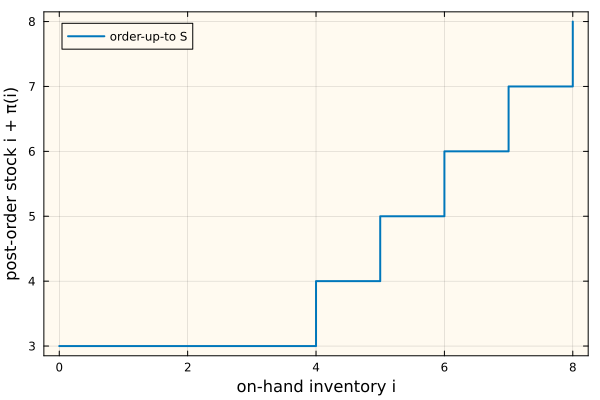

In [6]:
let
    order_up_to = [ (i) + (π_pi[i+1] - 1) for i ∈ 0:8 ];
    plot(0:8, order_up_to, seriestype = :steppost, lw = 2, c = colors[1], label = "order-up-to S",
        bg = "floralwhite", background_color_outside = "white", framestyle = :box,
        xlabel = "on-hand inventory i", ylabel = "post-order stock i + π(i)")
end

## Summary
This example built a capacity-8 single-item inventory MDP with stochastic demand, solved it with policy iteration, and verified the result against value iteration.

> __Key Takeaways:__
>
> * **Exact policy evaluation is a linear solve:** for a fixed policy $\pi$, the Bellman expectation equation is a system of $|\mathcal{S}|$ linear equations, solved directly as $\mathbf{V}^{\pi}=(\mathbf{I}-\gamma\mathbf{P}^{\pi})^{-1}\mathbf{R}^{\pi}$.
> * **Policy improvement is greedy with respect to $Q$:** given $V^{\pi}$, the improved policy takes $\pi^{\prime}(s)=\arg\max_{a}Q^{\pi}(s,a)$ at every state, and the policy improvement theorem guarantees $V^{\pi^{\prime}}(s)\ge V^{\pi}(s)$.
> * **Value iteration and policy iteration reach the same optimum:** on this inventory MDP the two algorithms produce identical policies and value functions, confirming both converge to $\pi^{\star}$ and $V^{\star}$.

Policy iteration alternates an exact linear solve with greedy improvement and converges to the optimal policy in a finite number of sweeps, trading many cheap value-iteration backups for a few expensive but exact evaluations. When the transition and reward model is fully known and the state space is small enough that the linear solve is cheap, this exactness makes policy iteration an attractive alternative to value iteration.
___

### Additional Resources
* Puterman, M. L. (1994). _Markov Decision Processes: Discrete Stochastic Dynamic Programming_. John Wiley & Sons.
* Bertsekas, D. P. (2017). _Dynamic Programming and Optimal Control_ (4th ed.). Athena Scientific.
* Sutton, R. S., & Barto, A. G. (2018). _Reinforcement Learning: An Introduction_ (2nd ed.). MIT Press.